In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.

df = pd.read_csv("C:\\Users\\bhoom\\Downloads\\matplotlib_sales_clean_1000 - matplotlib_sales_clean_1000.csv")
df.head()

,Order_ID,Order_Date,City,Product_Category,Customer_Segment,Customer_Age,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Gross_Sales,Discount_Amount,Revenue,Cost,Profit
0,ORD00849,2025-01-01,Pune,Home & Kitchen,Budget,36,5,13359.07,2.33,3.4,66795.35,1556.33,65239.02,45347.81,19891.21
1,ORD00678,2025-01-01,Hyderabad,Home & Kitchen,Premium,42,2,13594.04,19.92,3.9,27188.08,5415.87,21772.21,15198.49,6573.72
2,ORD00649,2025-01-01,Delhi,Home & Kitchen,Budget,25,5,1657.67,2.85,2.7,8288.35,236.22,8052.13,4569.99,3482.14
3,ORD00756,2025-01-01,Bengaluru,Home & Kitchen,Premium,31,3,2487.88,32.94,3.7,7463.64,2458.52,5005.12,3547.03,1458.09
4,ORD00992,2025-01-01,Delhi,Beauty,Regular,43,4,20911.12,26.06,4.2,83644.48,21797.75,61846.73,36979.40,24867.33


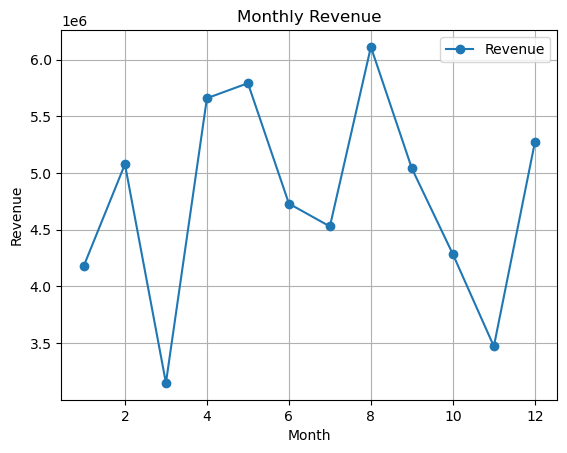

In [3]:
# 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

plt.plot(monthly.index, monthly.values, marker='o', label='Revenue')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()

plt.show()

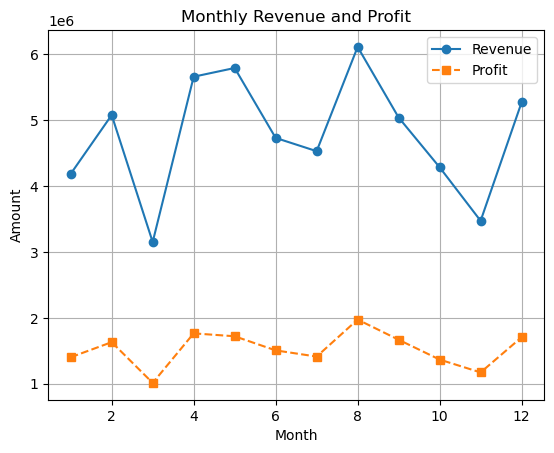

In [4]:
# 2. Plot monthly Revenue and Profit on the same chart using different line styles.

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly = df.groupby(df["Order_Date"].dt.month)[["Revenue", "Profit"]].sum()

plt.plot(monthly.index, monthly["Revenue"], linestyle='-', marker='o', label='Revenue')
plt.plot(monthly.index, monthly["Profit"], linestyle='--', marker='s', label='Profit')

plt.title("Monthly Revenue and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

plt.show()

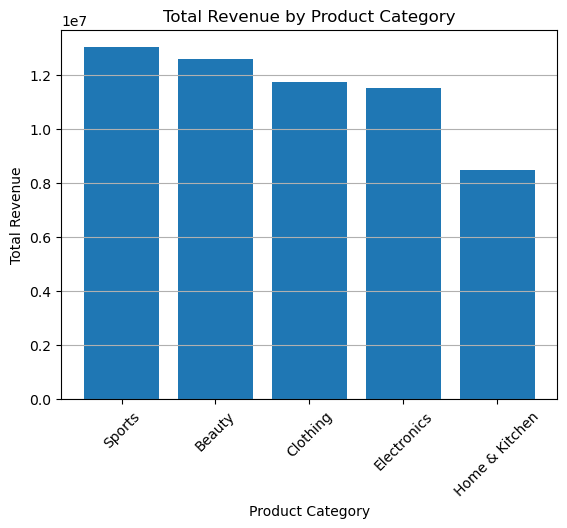

In [5]:
# 3. Create a bar chart of total Revenue by Product_Category and sort the categories
# from highest to lowest revenue.

category_revenue = df.groupby("Product_Category")["Revenue"].sum()
category_revenue = category_revenue.sort_values(ascending=False)

plt.bar(category_revenue.index, category_revenue.values)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

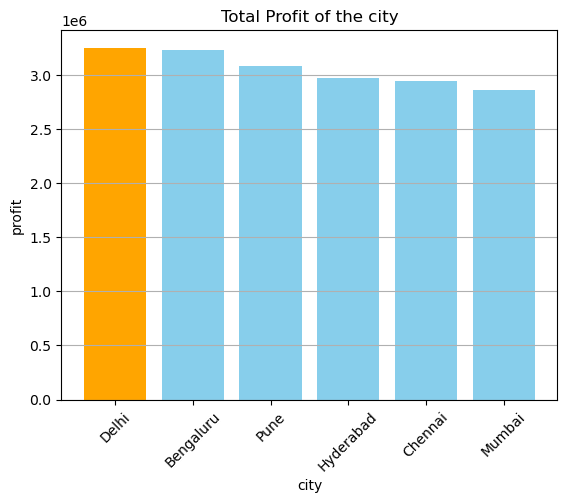

In [6]:
# 4. Create a bar chart of total Profit by City and highlight the city with the highest profit.

total_profit = df.groupby("City")["Profit"].sum()
total_profit = total_profit.sort_values(ascending=False)

highest_city = total_profit.idxmax()
colors = ["orange" if city == highest_city else "skyblue"
          for city in total_profit.index]

plt.bar(total_profit.index, total_profit.values, color=colors)

plt.title("Total Profit of the city")
plt.xlabel("city")
plt.ylabel("profit")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

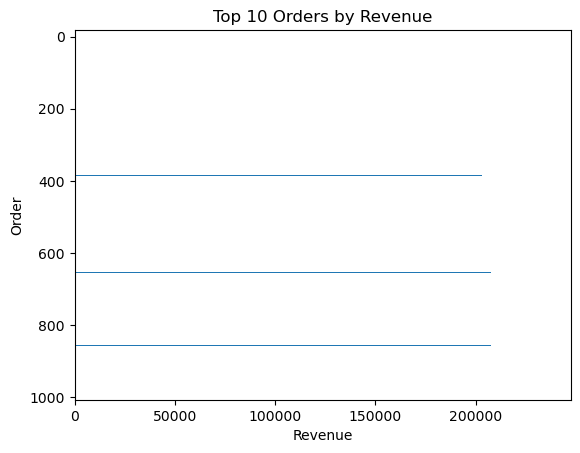

In [7]:
# 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.

top10 = df.sort_values("Revenue", ascending=False).head(10)

plt.barh(top10.index, top10["Revenue"])

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order")
plt.gca().invert_yaxis()

plt.show()

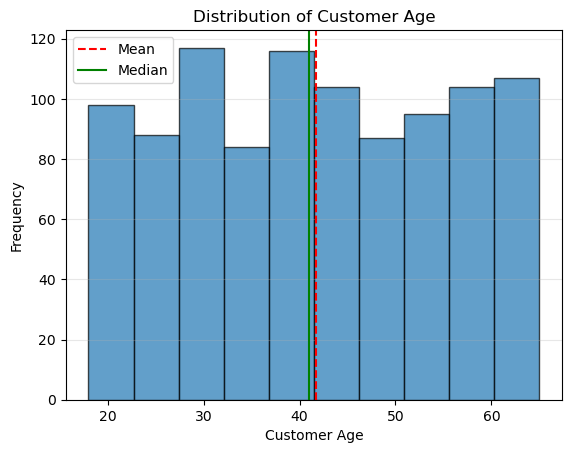

In [8]:
# 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and
#
median_age = df["Customer_Age"].median()
mean_age = df["Customer_Age"].mean()
plt.hist(df["Customer_Age"], bins=10, edgecolor="black", alpha=0.7)

plt.axvline(mean_age, color="red",linestyle="--", label="Mean")
plt.axvline(median_age, color="green", linestyle="-", label="Median")

plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


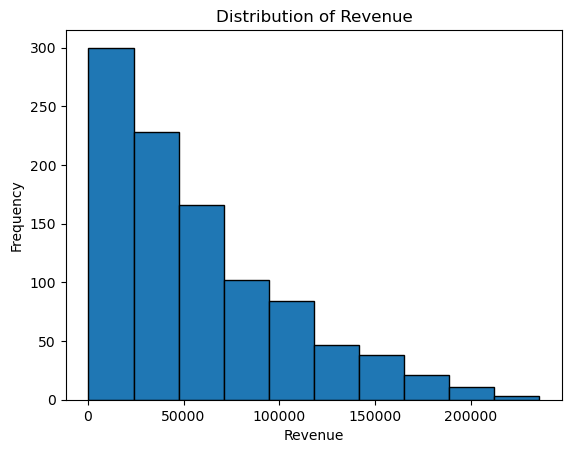

In [9]:
# 7. Create a histogram of Revenue and explain visually whether the distribution appears
# symmetric or skewed.

plt.hist(df["Revenue"], bins=10, edgecolor="black")

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

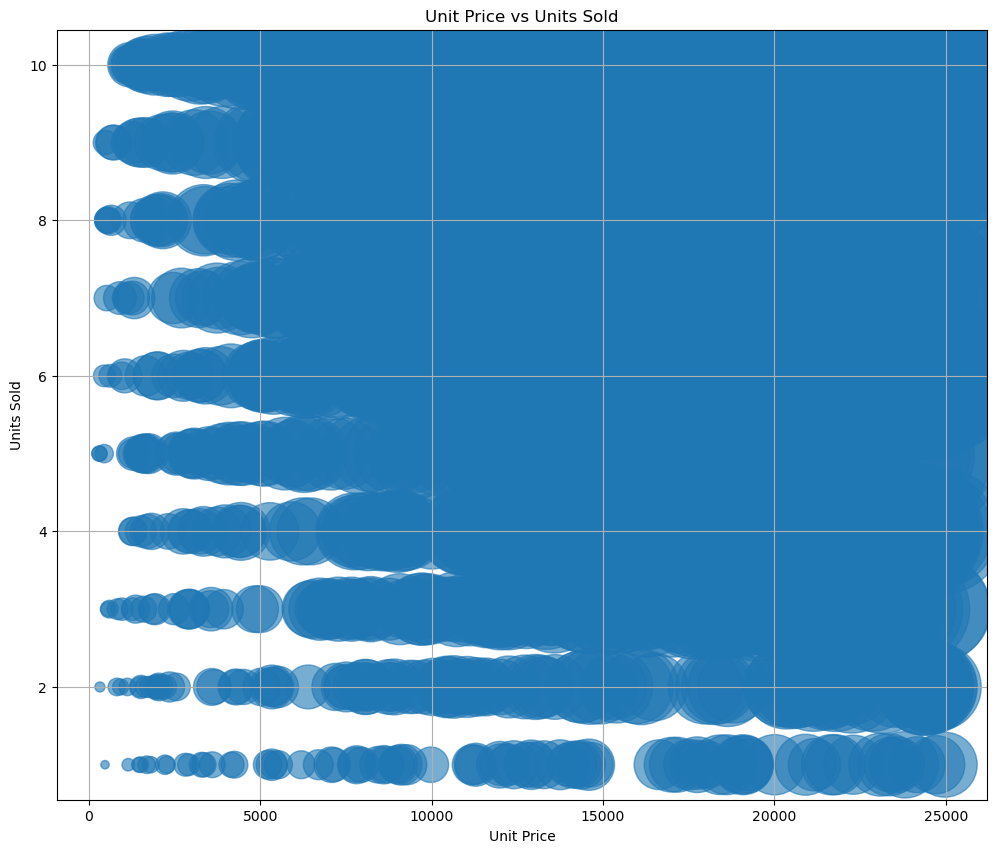

In [10]:
# 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on
# Revenue.
plt.figure(figsize = (12,10))
plt.scatter(df["Unit_Price"], df["Units_Sold"], s=df["Revenue"] / 10, alpha=0.6)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

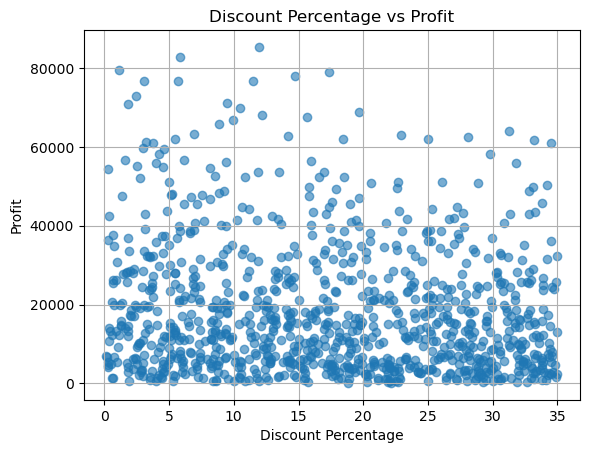

In [11]:
#9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher
#discounts are associated with lower profit.

plt.scatter(df["Discount_Pct"], df["Profit"], alpha=0.6)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")
plt.grid(True)

plt.show()


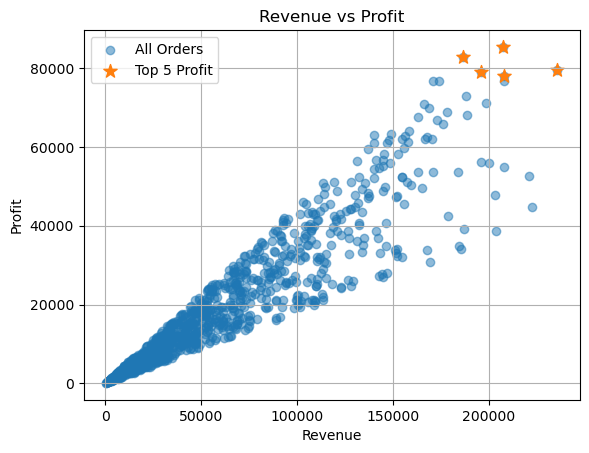

In [12]:
# 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the
#highest profit.

top5 = df.nlargest(5, "Profit")

# Scatter plot
plt.scatter(df["Revenue"], df["Profit"], alpha=0.5, label="All Orders")

# Highlight top 5
plt.scatter(top5["Revenue"], top5["Profit"], s=100, marker="*", label="Top 5 Profit")

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)

plt.show()

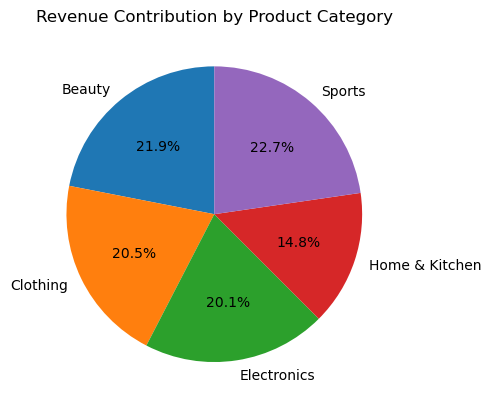

In [15]:
# 11. Create a pie chart of Revenue contribution by Product_Category. Display percentage
# values.

category_revenue = df.groupby("Product_Category")["Revenue"].sum()

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90)

plt.title("Revenue Contribution by Product Category")
plt.show()

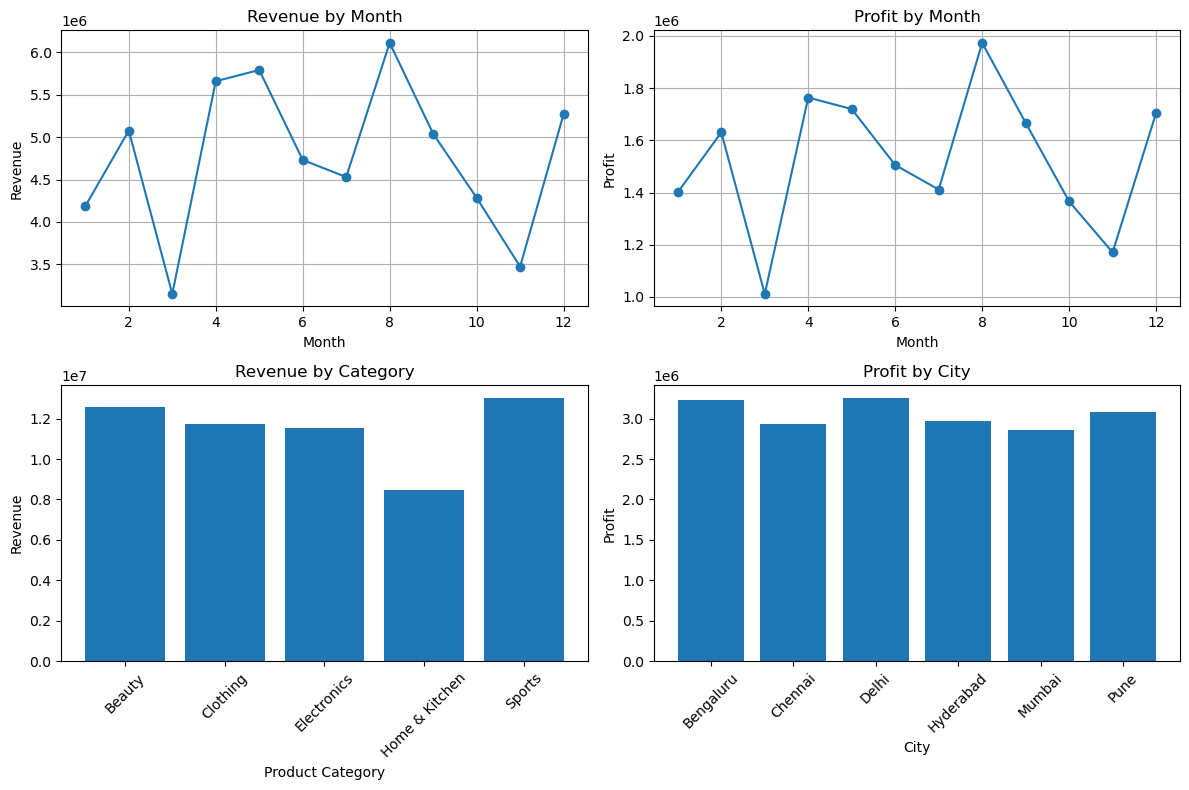

In [16]:
# 12. Create a 2×2 subplot containing:
# o Revenue by month
# o Profit by month
# o Revenue by category
# o Profit by city


monthly_revenue = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

monthly_profit = df.groupby(df["Order_Date"].dt.month)["Profit"].sum()

category_revenue = df.groupby("Product_Category")["Revenue"].sum()

city_profit = df.groupby("City")["Profit"].sum()


plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")
plt.title("Profit by Month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.bar(category_revenue.index, category_revenue.values)
plt.title("Revenue by Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
plt.bar(city_profit.index, city_profit.values)
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

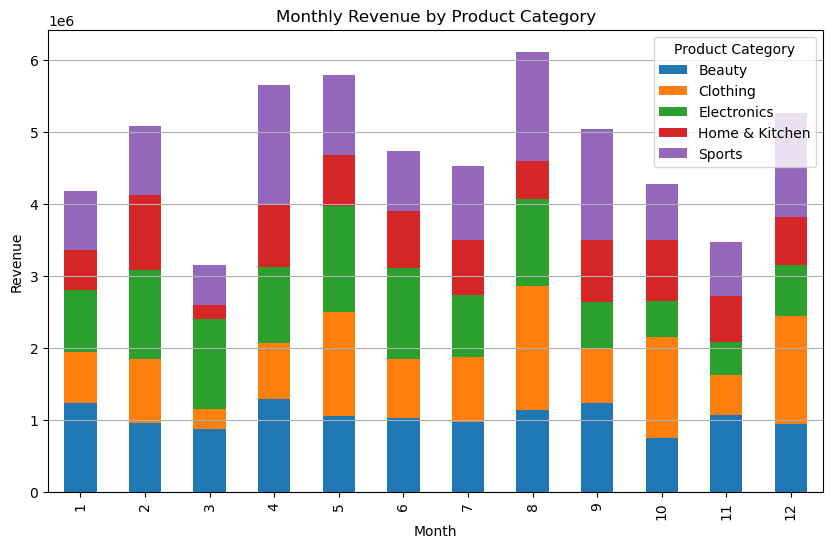

In [17]:
# 13. Create a stacked bar chart showing Revenue by month for each Product_Category.

monthly_category = df.groupby(
    [df["Order_Date"].dt.month, "Product_Category"]
)["Revenue"].sum().unstack()

monthly_category.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.grid(axis="y")
plt.show()

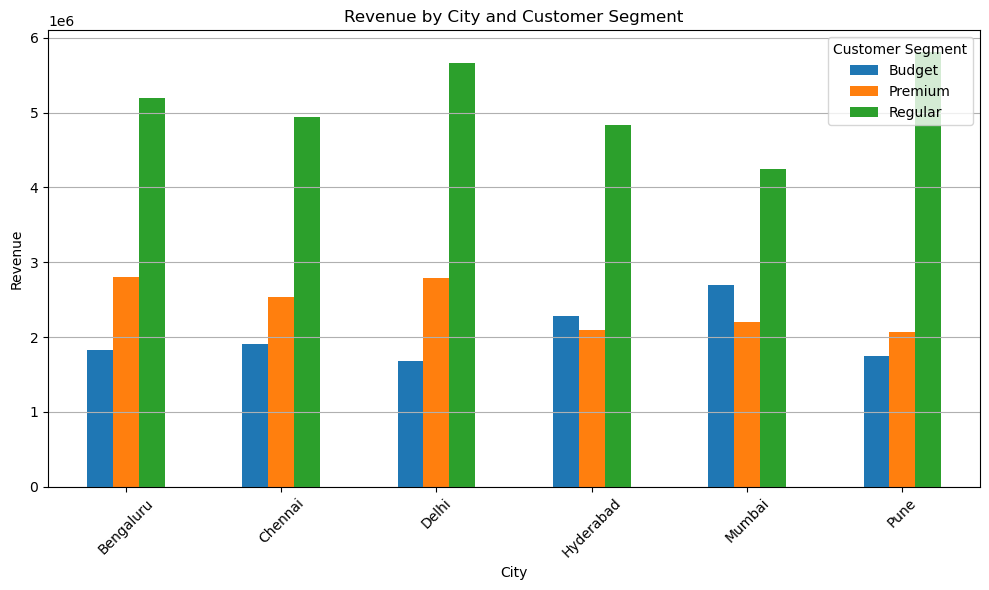

In [18]:
# 14. Create a grouped bar chart comparing Revenue across cities for different customer segments.


city_segment = df.groupby(["City", "Customer_Segment"])["Revenue"].sum().unstack()

city_segment.plot(
    kind="bar",
    figsize=(10, 6))

plt.title("Revenue by City and Customer Segment")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.legend(title="Customer Segment")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

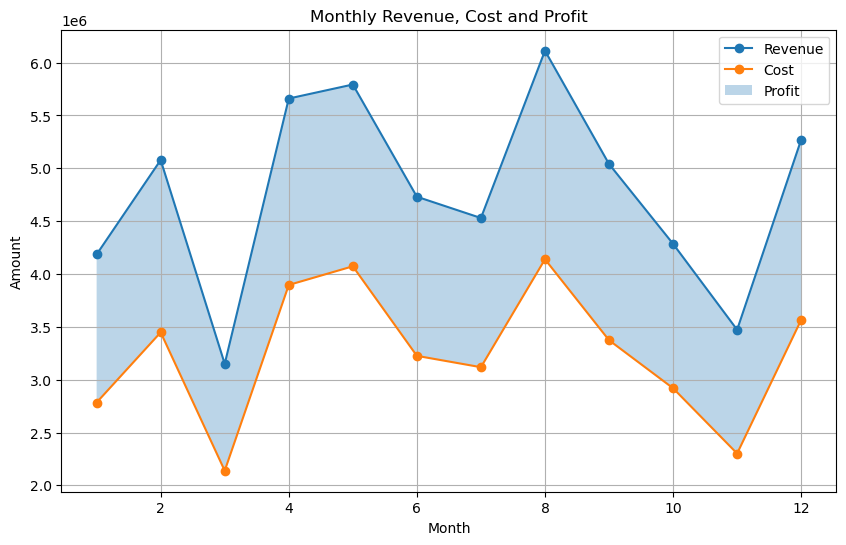

In [19]:
# 15. Plot monthly Revenue and Cost together and shade the area between the two lines to represent Profit.

monthly = df.groupby(df["Order_Date"].dt.month)[["Revenue", "Cost"]].sum()

plt.figure(figsize=(10, 6))

plt.plot(monthly.index, monthly["Revenue"], marker="o", label="Revenue")
plt.plot(monthly.index, monthly["Cost"], marker="o", label="Cost")

plt.fill_between(
    monthly.index,
    monthly["Revenue"],
    monthly["Cost"],
    alpha=0.3,
    label="Profit")

plt.title("Monthly Revenue, Cost and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

plt.show()

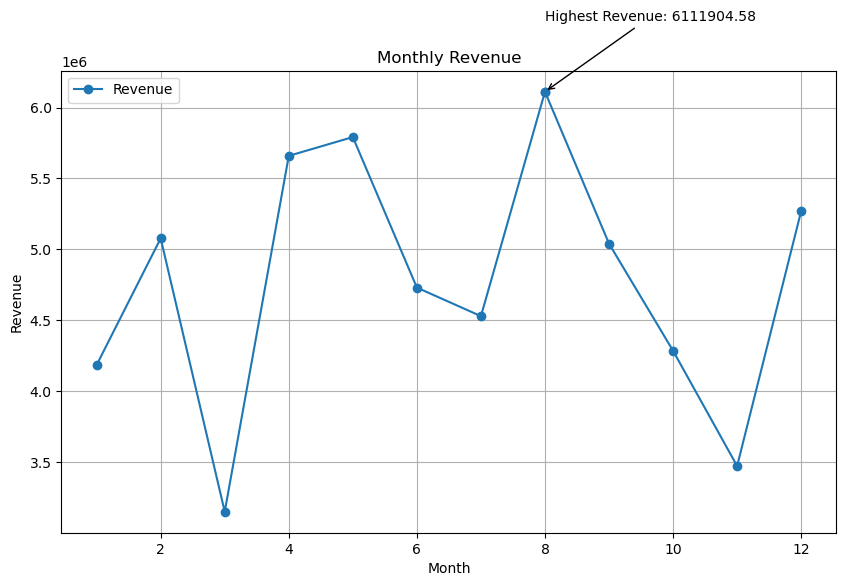

In [20]:
# 16. Find the month with the highest Revenue and annotate that point on the line chart.

monthly = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

max_month = monthly.idxmax()
max_revenue = monthly.max()

plt.figure(figsize=(10, 6))

plt.plot(monthly.index, monthly.values, marker="o", label="Revenue")

plt.scatter(max_month, max_revenue)

plt.annotate(
    f"Highest Revenue: {max_revenue:.2f}",
    xy=(max_month, max_revenue),
    xytext=(max_month, max_revenue + 500000),
    arrowprops=dict(arrowstyle="->"))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

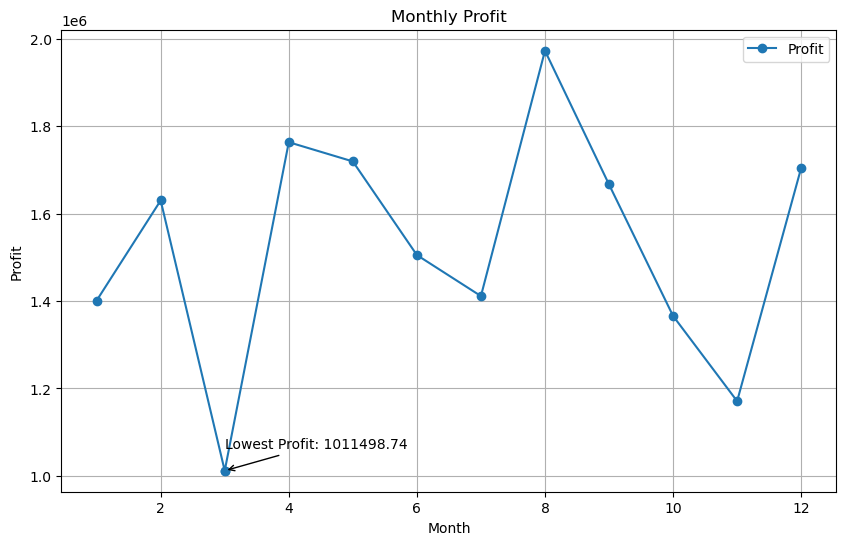

In [21]:
# 17. Find the month with the lowest Profit and annotate it on the visualization.

monthly = df.groupby(df["Order_Date"].dt.month)["Profit"].sum()

min_month = monthly.idxmin()
min_profit = monthly.min()

plt.figure(figsize=(10, 6))

plt.plot(monthly.index, monthly.values, marker="o", label="Profit")

plt.scatter(min_month, min_profit)

plt.annotate(
    f"Lowest Profit: {min_profit:.2f}",
    xy=(min_month, min_profit),
    xytext=(min_month, min_profit + 50000),
    arrowprops=dict(arrowstyle="->"))

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)

plt.show()

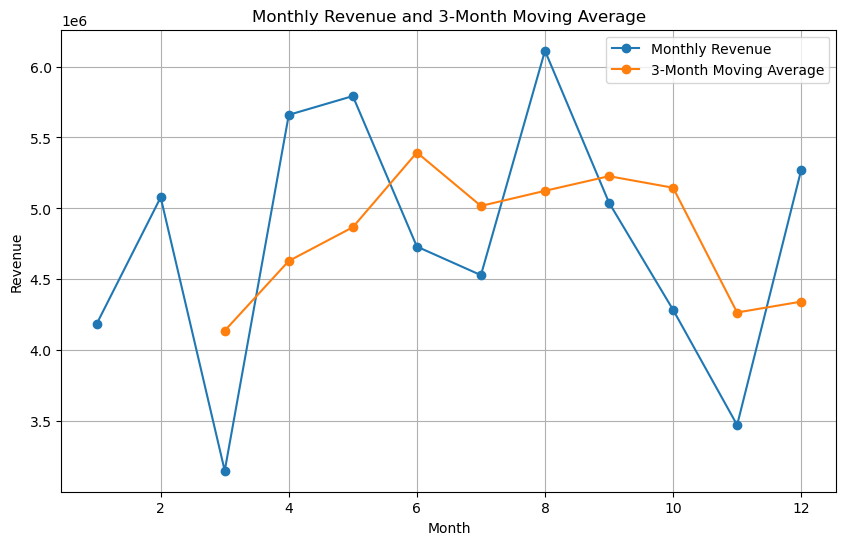

In [22]:
# 18. Create a line chart of monthly Revenue and calculate a 3-month moving average.
# Plot both lines together.

monthly = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

moving_avg = monthly.rolling(3).mean()

plt.figure(figsize=(10, 6))

plt.plot(monthly.index, monthly.values, marker="o", label="Monthly Revenue")
plt.plot(monthly.index, moving_avg, marker="o", label="3-Month Moving Average")

plt.title("Monthly Revenue and 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

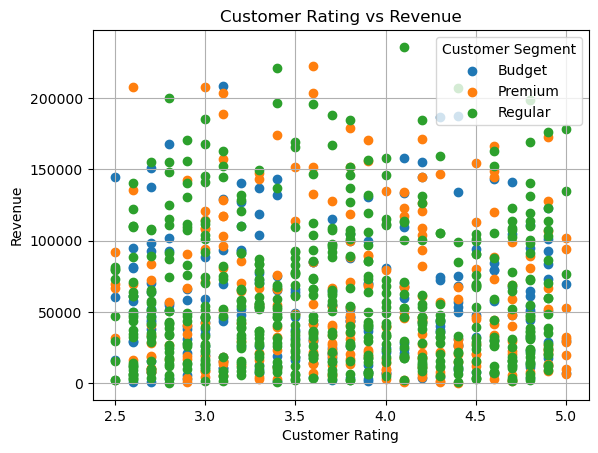

In [23]:
# 19. Create a scatter plot between Customer_Rating and Revenue. Use
# Customer_Segment to visually distinguish the points.

segments = df["Customer_Segment"].unique()

for segment in segments:
    data = df[df["Customer_Segment"] == segment]
    plt.scatter(
        data["Customer_Rating"],
        data["Revenue"],
        label=segment)

plt.title("Customer Rating vs Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")
plt.legend(title="Customer Segment")
plt.grid(True)

plt.show()

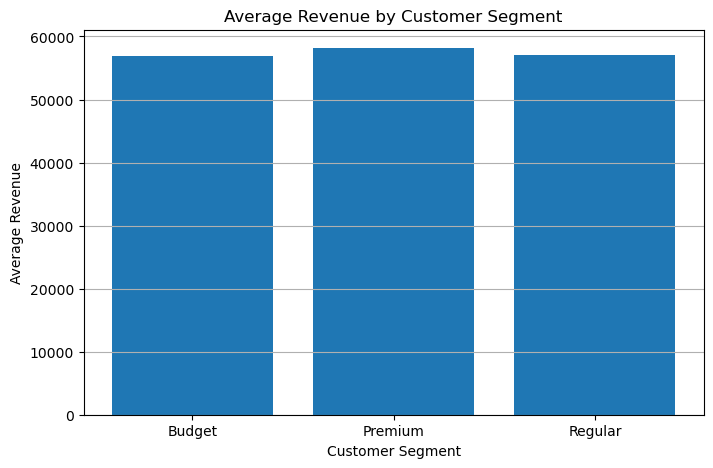

In [24]:
# 20. Create a visualization comparing the average Revenue of Premium, Regular, and Budget customers.

avg_revenue = df.groupby("Customer_Segment")["Revenue"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_revenue.index, avg_revenue.values)

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")

plt.grid(axis="y")
plt.show()

In [26]:
# 21. Create a boxplot of Revenue for each Customer_Segment. Compare the distributions visually.


In [27]:
# 22. Create boxplots of Revenue for each Product_Category and identify which category
# has the largest spread.

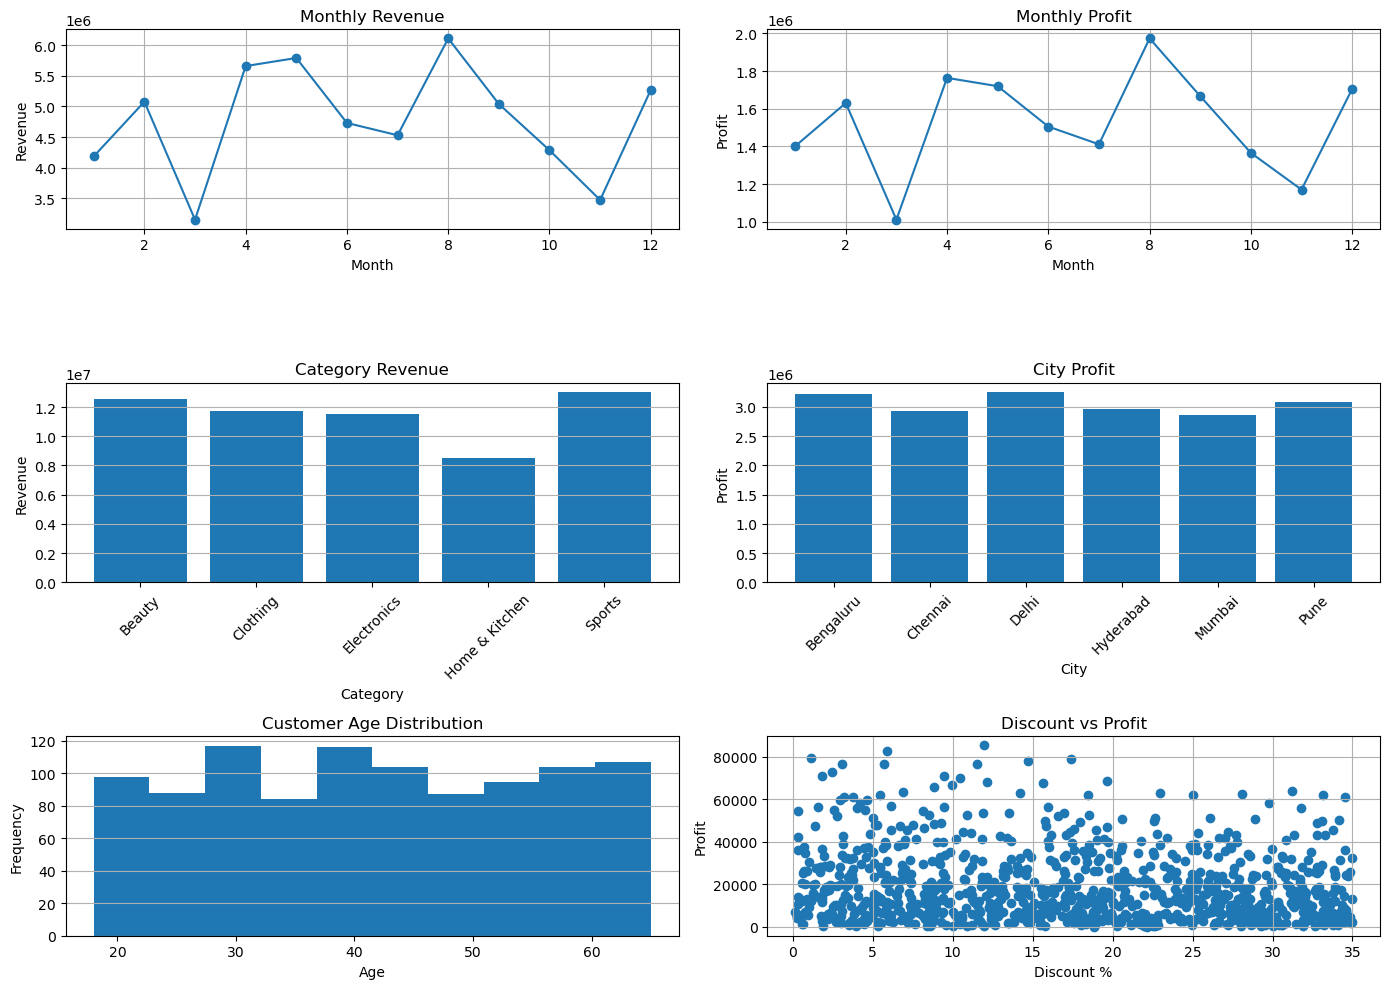

In [28]:
# 23. Create a 3×2 Matplotlib dashboard containing:
# o Monthly revenue
# o Monthly profit
# o Category revenue
#o City profit
#o Customer-age distribution
#o Discount vs profit

monthly_revenue = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()
monthly_profit = df.groupby(df["Order_Date"].dt.month)["Profit"].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
city_profit = df.groupby("City")["Profit"].sum()

plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)

plt.subplot(3, 2, 3)
plt.bar(category_revenue.index, category_revenue.values)
plt.title("Category Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.subplot(3, 2, 4)
plt.bar(city_profit.index, city_profit.values)
plt.title("City Profit")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.subplot(3, 2, 5)
plt.hist(df["Customer_Age"], bins=10)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y")

plt.subplot(3, 2, 6)
plt.scatter(df["Discount_Pct"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount %")
plt.ylabel("Profit")
plt.grid(True)

plt.tight_layout()
plt.show()

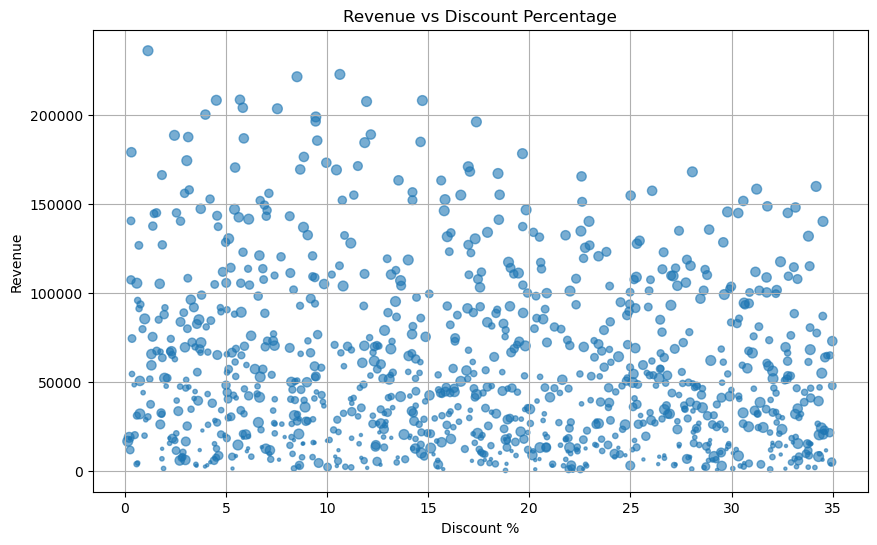

In [29]:
# 24. Create a chart showing Revenue vs Discount_Pct and use marker size to represent Units_Sold.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Revenue"],
    s=df["Units_Sold"] * 5,
    alpha=0.6
)

plt.title("Revenue vs Discount Percentage")
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

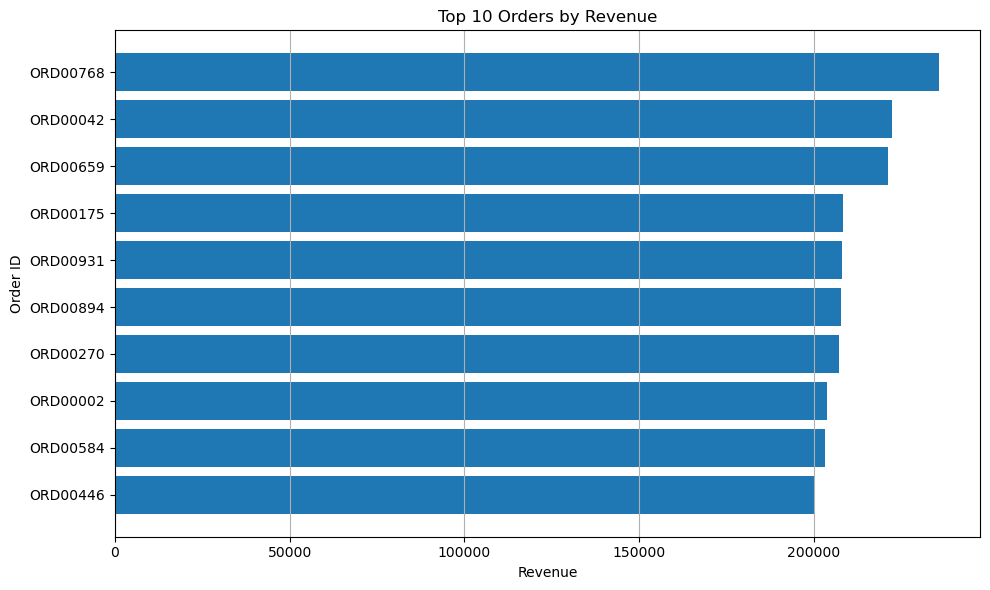

In [30]:
# 25. Identify the top 10 highest-revenue orders and visualize them using a horizontal bar
# chart. Display the Order_ID beside each bar.

top_10 = df.sort_values("Revenue", ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_10["Order_ID"].astype(str), top_10["Revenue"])

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")

plt.gca().invert_yaxis()

plt.grid(axis="x")
plt.tight_layout()
plt.show()

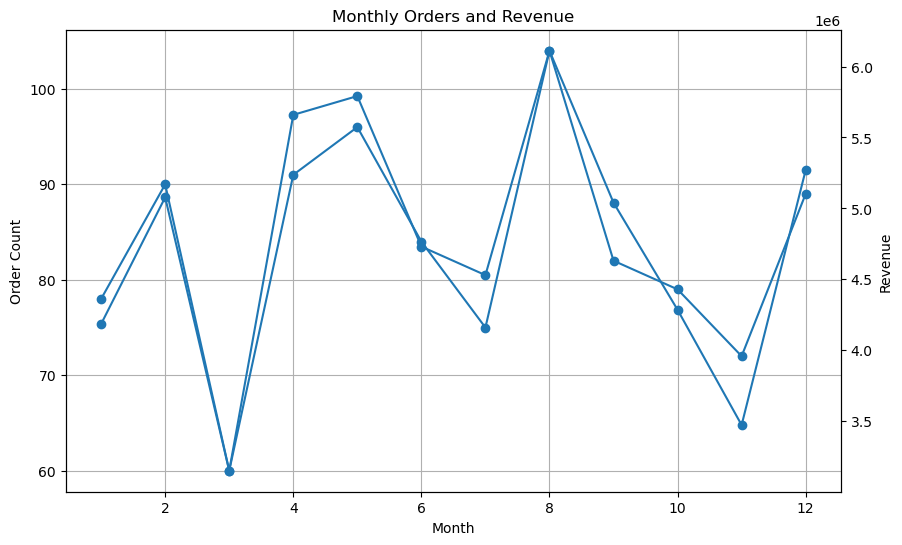

In [31]:
# 26. Create a visualization showing monthly Orders and Revenue using two Y-axes. Use
# the first Y-axis for order count and the second for revenue.

monthly_orders = df.groupby(df["Order_Date"].dt.month)["Order_ID"].count()

monthly_revenue = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o",
    label="Orders")

ax1.set_xlabel("Month")
ax1.set_ylabel("Order Count")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Revenue")

ax2.set_ylabel("Revenue")

plt.title("Monthly Orders and Revenue")

plt.show()

In [33]:
# 27. Create a heatmap-style visualization using Matplotlib only for the correlation matrix of:
# Customer_Age, Units_Sold, Unit_Price, Discount_Pct, Revenue, Cost, and Profit.


In [34]:
# 28. Create a dashboard comparing City × Product_Category Revenue. Use a suitable
# visualization to show which combinations generate the highest revenue.

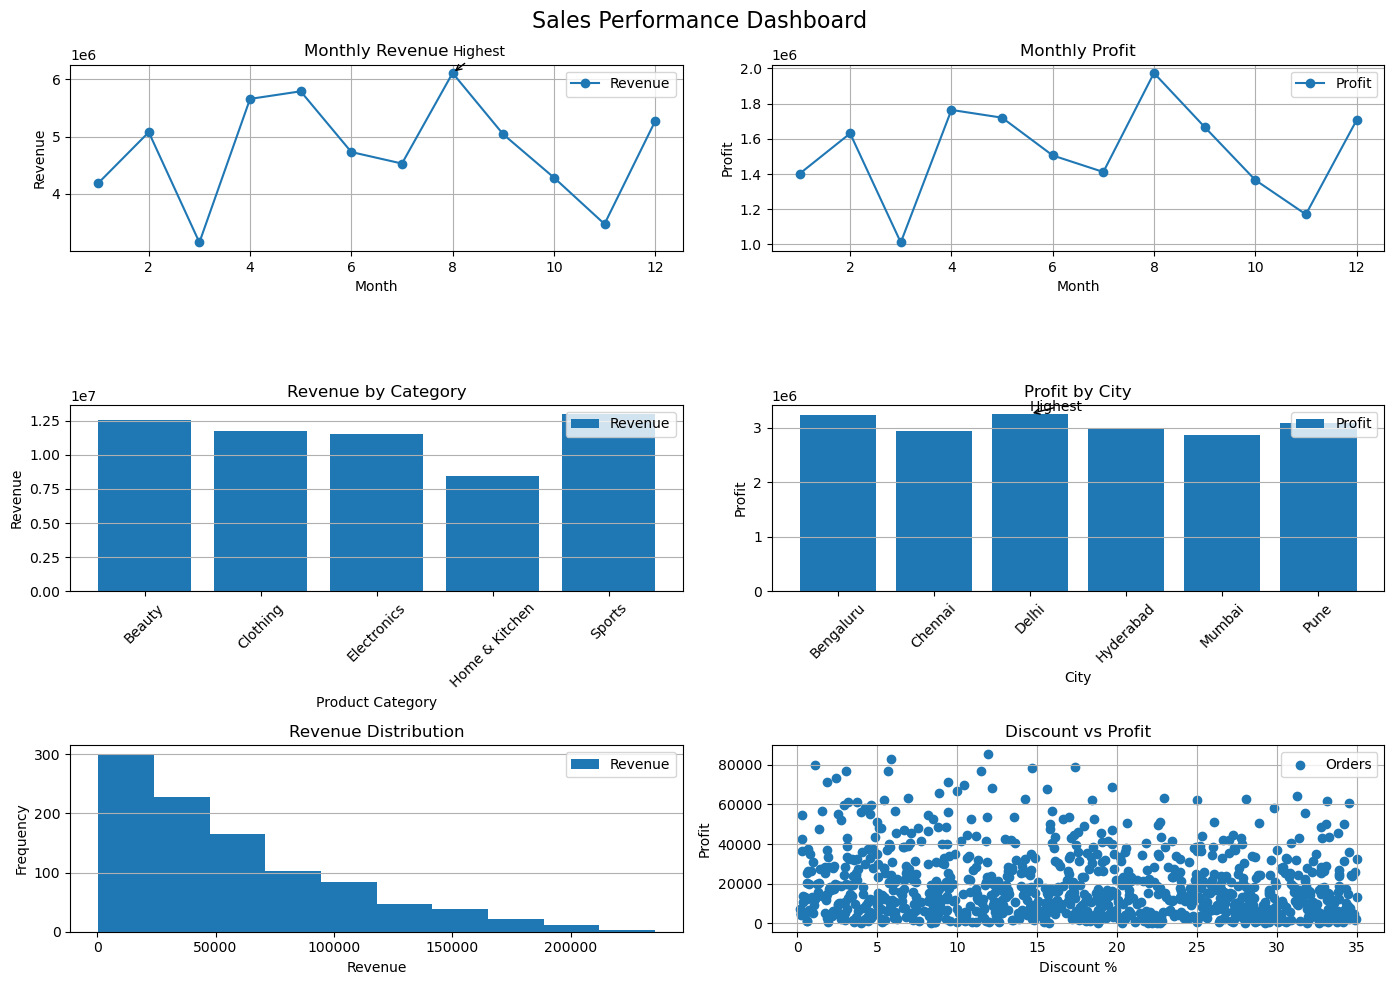

In [35]:
# 29. Create a complete sales performance dashboard with:
#o Monthly Revenueo Monthly Profit
#o Revenue by Category
#o Profit by City
#o Revenue distribution
#o Discount vs Profit
#Add titles, labels, legends, grids, annotations, and appropriate figure sizing.


monthly_revenue = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()
monthly_profit = df.groupby(df["Order_Date"].dt.month)["Profit"].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
city_profit = df.groupby("City")["Profit"].sum()

plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker="o", label="Revenue")

max_month = monthly_revenue.idxmax()
max_revenue = monthly_revenue.max()

plt.annotate(
    "Highest",
    xy=(max_month, max_revenue),
    xytext=(max_month, max_revenue + 300000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 2)
plt.plot(monthly_profit.index, monthly_profit.values,
         marker="o", label="Profit")

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 3)
plt.bar(category_revenue.index, category_revenue.values,
        label="Revenue")

plt.title("Revenue by Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")

plt.subplot(3, 2, 4)
plt.bar(city_profit.index, city_profit.values,
        label="Profit")

max_city = city_profit.idxmax()
max_city_profit = city_profit.max()

plt.annotate(
    "Highest",
    xy=(list(city_profit.index).index(max_city), max_city_profit),
    xytext=(list(city_profit.index).index(max_city), max_city_profit + 50000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")

plt.subplot(3, 2, 5)
plt.hist(df["Revenue"], bins=10, label="Revenue")

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y")

plt.subplot(3, 2, 6)
plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    label="Orders"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount %")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)


plt.suptitle("Sales Performance Dashboard", fontsize=16)

plt.tight_layout()
plt.show()

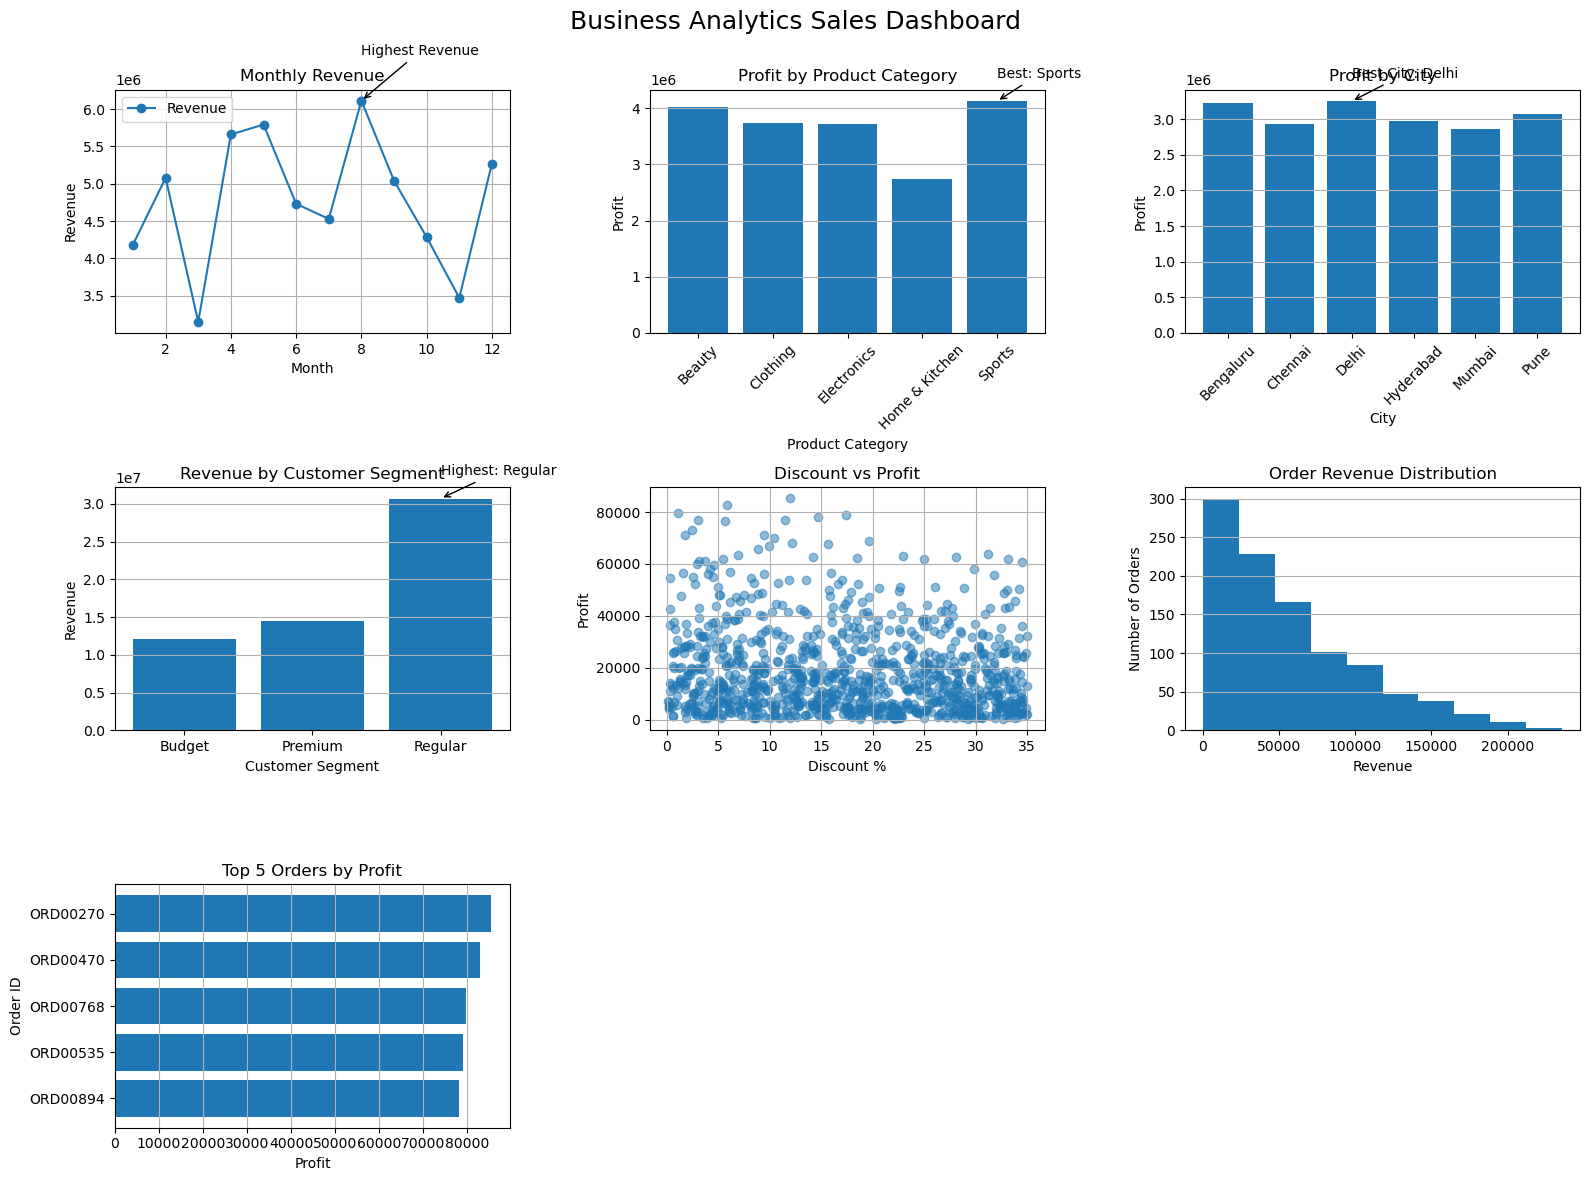

In [37]:
# 30. Final Challenge — Business Analytics Visualization
# Using the complete dataset, create a professional Matplotlib dashboard that answers:o Which month generated the highest revenue?
#o Which product category generated the highest profit?
#o Which city performed best?
#o Which customer segment generated the most revenue?
#o Does discount appear to affect profit?
#o What is the distribution of order revenue?
#o Which 5 orders generated the highest profit?
#Use at least 6 different visualizations, combine them into subplots, and add meaningful
#annotations to the important findings.

monthly_revenue = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

category_profit = df.groupby("Product_Category")["Profit"].sum()

city_profit = df.groupby("City")["Profit"].sum()

segment_revenue = df.groupby("Customer_Segment")["Revenue"].sum()

top_5_profit = df.sort_values("Profit", ascending=False).head(5)


highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

best_category = category_profit.idxmax()
highest_category_profit = category_profit.max()

best_city = city_profit.idxmax()
highest_city_profit = city_profit.max()

best_segment = segment_revenue.idxmax()
highest_segment_revenue = segment_revenue.max()

plt.figure(figsize=(16, 12))

plt.subplot(3, 3, 1)

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)

plt.scatter(
    highest_month,
    highest_revenue
)

plt.annotate(
    "Highest Revenue",
    xy=(highest_month, highest_revenue),
    xytext=(highest_month, highest_revenue * 1.1),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.subplot(3, 3, 2)

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.annotate(
    f"Best: {best_category}",
    xy=(
        list(category_profit.index).index(best_category),
        highest_category_profit
    ),
    xytext=(
        list(category_profit.index).index(best_category),
        highest_category_profit * 1.1
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.subplot(3, 3, 3)

plt.bar(
    city_profit.index,
    city_profit.values
)

plt.annotate(
    f"Best City: {best_city}",
    xy=(
        list(city_profit.index).index(best_city),
        highest_city_profit
    ),
    xytext=(
        list(city_profit.index).index(best_city),
        highest_city_profit * 1.1
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.subplot(3, 3, 4)

plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.annotate(
    f"Highest: {best_segment}",
    xy=(
        list(segment_revenue.index).index(best_segment),
        highest_segment_revenue
    ),
    xytext=(
        list(segment_revenue.index).index(best_segment),
        highest_segment_revenue * 1.1
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.grid(axis="y")

plt.subplot(3, 3, 5)

plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount %")
plt.ylabel("Profit")
plt.grid(True)

plt.subplot(3, 3, 6)

plt.hist(
    df["Revenue"],
    bins=10
)

plt.title("Order Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")
plt.grid(axis="y")


plt.subplot(3, 3, 7)

plt.barh(
    top_5_profit["Order_ID"].astype(str),
    top_5_profit["Profit"]
)

plt.title("Top 5 Orders by Profit")
plt.xlabel("Profit")
plt.ylabel("Order ID")

plt.gca().invert_yaxis()
plt.grid(axis="x")


plt.suptitle(
    "Business Analytics Sales Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()